In [23]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
import os
from datetime import datetime

# prettier plots
sns.set(style="whitegrid")

# Paths
PARQUET_PATH = r"C:\Users\marie\Documents\Polimi\Project\dataset"   
OUT_DIR = r"C:\Users\marie\Documents\Polimi\Project\bluesky_eda_outputs"
os.makedirs(OUT_DIR, exist_ok=True)

# Date range (April 2025)
START = "2025-03-17T00:00:00Z"
END   = "2025-04-30T23:59:59Z"

con = duckdb.connect()


In [24]:
schema = con.execute(f"DESCRIBE SELECT * FROM read_parquet('{PARQUET_PATH}') LIMIT 1").fetchdf()
display(schema)


,column_name,column_type,null,key,default,extra
0,did_id,BIGINT,YES,None,None,None
1,rkey,VARCHAR,YES,None,None,None
2,created_at,TIMESTAMP WITH TIME ZONE,YES,None,None,None
3,subject_id,BIGINT,YES,None,None,None


In [25]:
sql = f"""
SELECT *
FROM read_parquet('{PARQUET_PATH}')
WHERE created_at >= '{START}' AND created_at <= '{END}'
"""
blocks = con.execute(sql).fetchdf()
blocks['created_at'] = pd.to_datetime(blocks['created_at'], utc=True)

print(f"Rows loaded: {len(blocks):,}")
blocks.head()


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Rows loaded: 10,892,286


,did_id,rkey,created_at,subject_id
0,16,3llypftynss2z,2025-04-04 15:14:26.546000+00:00,13680162
1,57,3lmdexjpe2d2o,2025-04-08 21:06:45.334000+00:00,29924665
2,57,3lmgbwyws542x,2025-04-10 00:50:46.570000+00:00,9420413
3,115,3lkoo4wmcrp27,2025-03-18 21:59:44.732000+00:00,27730302
4,126,3llz6vctkj22s,2025-04-04 19:51:31.993000+00:00,24412694


In [26]:
total_events = len(blocks)
unique_blockers = blocks['did_id'].nunique()
unique_blocked = blocks['subject_id'].nunique()

print("Total block events:", total_events)
print("Unique blockers:", unique_blockers)
print("Unique blocked subjects:", unique_blocked)
print("Time range:", blocks['created_at'].min(), "→", blocks['created_at'].max())


Total block events: 10892286
Unique blockers: 934728
Unique blocked subjects: 2326078
Time range: 2025-03-17 00:00:00.670000+00:00 → 2025-04-18 06:41:44.570000+00:00


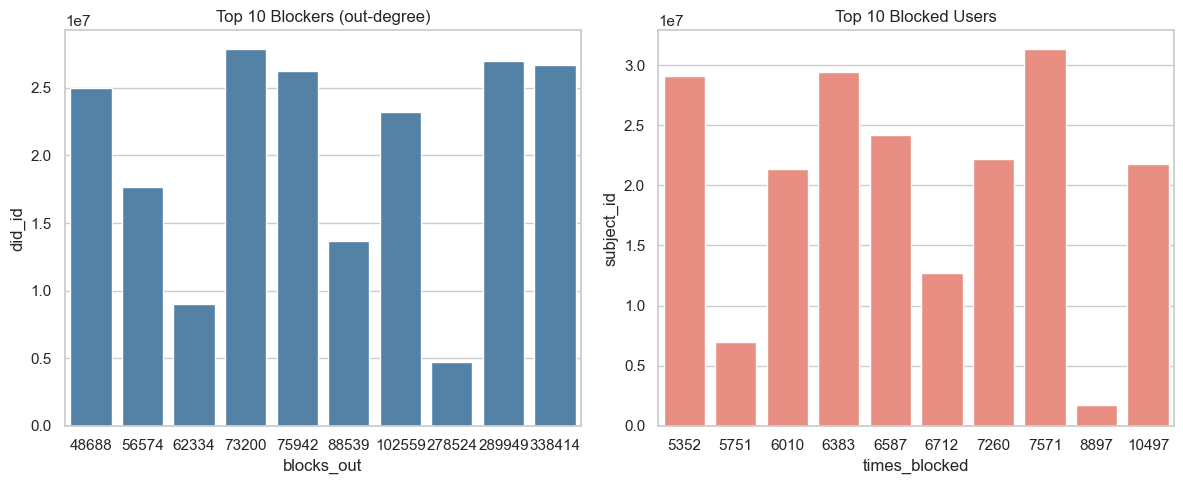

In [27]:
top_blockers = blocks['did_id'].value_counts().rename_axis('did_id').reset_index(name='blocks_out')
top_blocked  = blocks['subject_id'].value_counts().rename_axis('subject_id').reset_index(name='times_blocked')

fig, axes = plt.subplots(1,2, figsize=(12,5))
sns.barplot(x='blocks_out', y='did_id', data=top_blockers.head(10), ax=axes[0], color="steelblue")
sns.barplot(x='times_blocked', y='subject_id', data=top_blocked.head(10), ax=axes[1], color="salmon")
axes[0].set_title("Top 10 Blockers (out-degree)")
axes[1].set_title("Top 10 Blocked Users")
plt.tight_layout()
plt.show()


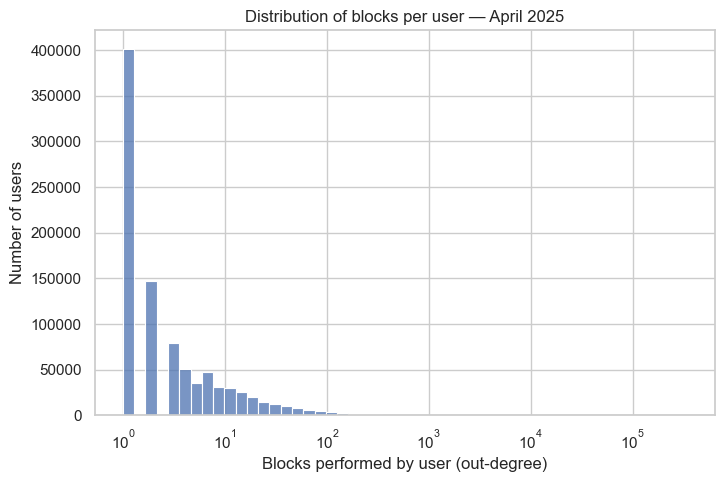

In [28]:
blocks_per_user = blocks.groupby('did_id').size().rename('out_degree').reset_index()

plt.figure(figsize=(8,5))
sns.histplot(blocks_per_user['out_degree'], bins=50, log_scale=(True, False))
plt.xlabel("Blocks performed by user (out-degree)")
plt.ylabel("Number of users")
plt.title("Distribution of blocks per user — April 2025")
plt.show()


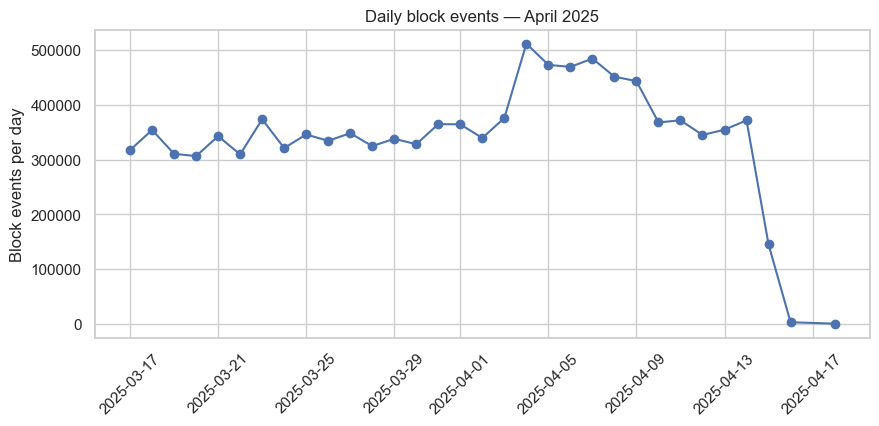

In [29]:
blocks['date'] = blocks['created_at'].dt.tz_convert('Europe/Rome').dt.date
daily_counts = blocks.groupby('date').size().rename('count').reset_index()

plt.figure(figsize=(10,4))
plt.plot(daily_counts['date'], daily_counts['count'], marker='o')
plt.xticks(rotation=45)
plt.ylabel('Block events per day')
plt.title('Daily block events — April 2025')
plt.show()


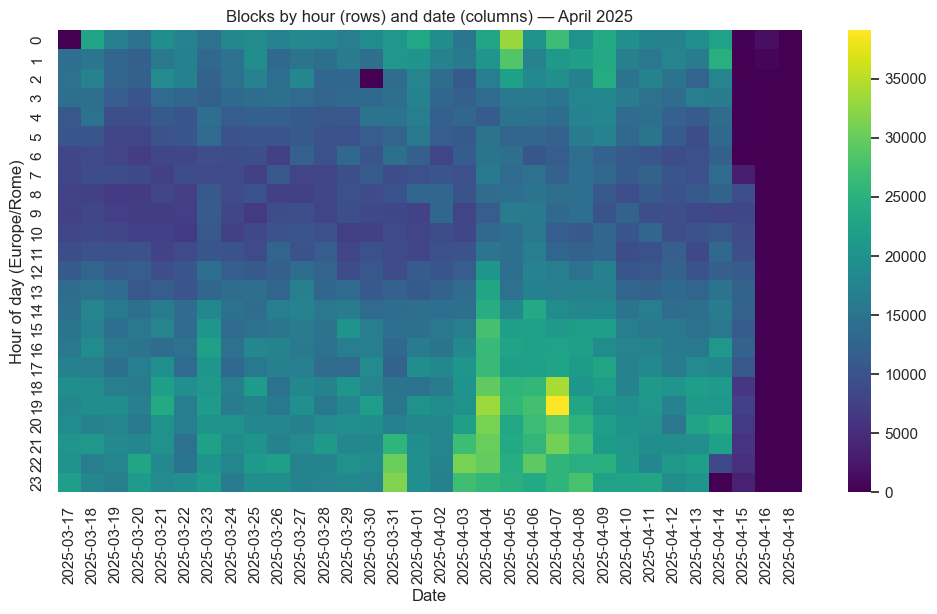

In [30]:
blocks['hour'] = blocks['created_at'].dt.tz_convert('Europe/Rome').dt.hour
hourly = blocks.groupby(['date','hour']).size().rename('count').reset_index()
pivot = hourly.pivot(index='hour', columns='date', values='count').fillna(0)

plt.figure(figsize=(12,6))
sns.heatmap(pivot, cmap='viridis')
plt.title('Blocks by hour (rows) and date (columns) — April 2025')
plt.ylabel('Hour of day (Europe/Rome)')
plt.xlabel('Date')
plt.show()


In [31]:
pairs = set((a,b) for a,b in blocks[['did_id','subject_id']].itertuples(index=False, name=None))
mutual_unique = {tuple(sorted((a,b))) for (a,b) in pairs if (b,a) in pairs}
print("Mutual block pairs:", len(mutual_unique))

mutual_df = pd.DataFrame(list(mutual_unique), columns=['did_a','did_b'])
mutual_df.head()


Mutual block pairs: 141572


,did_a,did_b
0,14398724,31420668
1,14357169,23079341
2,6735241,15004147
3,22368695,24883572
4,1283394,25791218


In [32]:
MAX_EDGES = 200000  
edges_df = blocks[['did_id','subject_id']].head(MAX_EDGES)

G = nx.DiGraph()
G.add_edges_from(edges_df.itertuples(index=False, name=None))
print(f"Graph — Nodes: {G.number_of_nodes():,}, Edges: {G.number_of_edges():,}")

# Degree centrality
deg_df = pd.DataFrame({
    'did_id': list(G.nodes),
    'in_degree': [G.in_degree(n) for n in G.nodes],
    'out_degree': [G.out_degree(n) for n in G.nodes],
})
deg_df['degree_sum'] = deg_df['in_degree'] + deg_df['out_degree']
deg_df.sort_values('degree_sum', ascending=False).head(10)


Graph — Nodes: 131,560, Edges: 198,442


,did_id,in_degree,out_degree,degree_sum
83424,644092,2,6616,6618
28901,522935,5,5031,5036
58649,392172,3,2734,2737
44558,200392,0,2669,2669
48991,217869,1,2128,2129
35658,177722,2,1905,1907
12084,51075,3,1448,1451
8353,632907,15,1230,1245
44445,253017,2,1183,1185
105284,590704,2,1181,1183


In [33]:
try:
    pr = nx.pagerank(G, alpha=0.85)
    pr_df = pd.DataFrame(pr.items(), columns=['did_id','pagerank']).sort_values('pagerank', ascending=False)
    pr_df.head(10)
except Exception as e:
    print("Pagerank failed:", e)


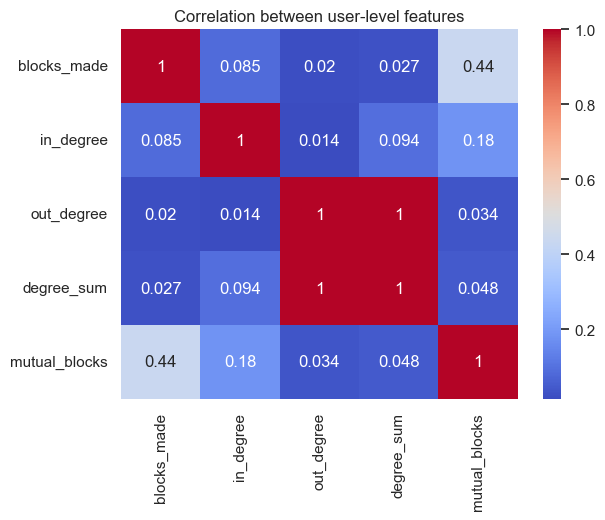

In [34]:
# Combine user-level features
blocker_counts = blocks.groupby('did_id').size().rename('blocks_made').reset_index()
blocked_counts = blocks.groupby('subject_id').size().rename('times_blocked').reset_index()
feat = blocker_counts.merge(deg_df, on='did_id', how='left').fillna(0)

mutual_counts = pd.Series([u for pair in mutual_unique for u in pair]).value_counts().rename_axis('did_id').reset_index(name='mutual_blocks')
feat = feat.merge(mutual_counts, on='did_id', how='left').fillna(0)

feat_corr = feat[['blocks_made','in_degree','out_degree','degree_sum','mutual_blocks']].corr()
sns.heatmap(feat_corr, annot=True, cmap='coolwarm')
plt.title('Correlation between user-level features')
plt.show()


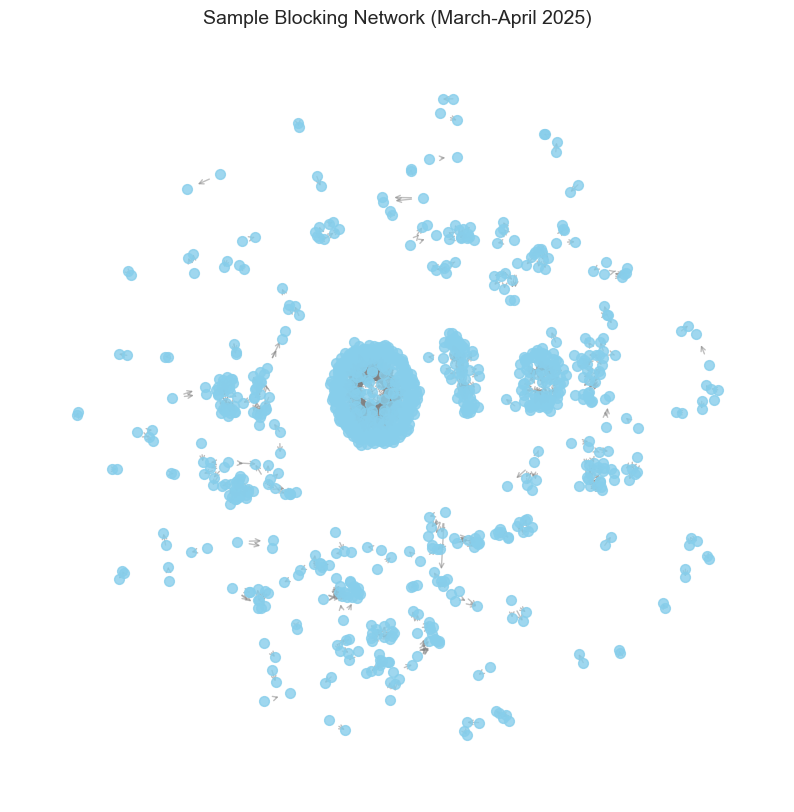

In [40]:
# A small subset for clarity
sample_nodes = list(G.nodes())[:1000]  
H = G.subgraph(sample_nodes)

plt.figure(figsize=(10, 10))
pos = nx.spring_layout(H, seed=42, k=0.25)  # layout algorithm
nx.draw_networkx_nodes(H, pos, node_size=50, node_color='skyblue', alpha=0.8)
nx.draw_networkx_edges(H, pos, arrowstyle='->', arrowsize=8, edge_color='gray', alpha=0.5)
plt.title("Sample Blocking Network (March-April 2025)", fontsize=14)
plt.axis("off")
plt.show()


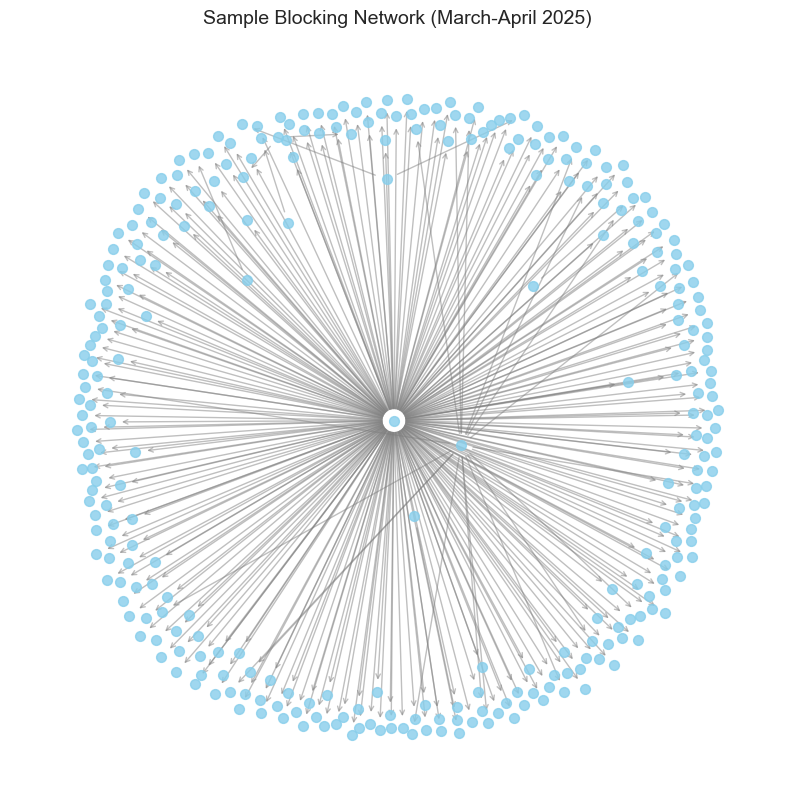

In [42]:
# A small subset for clarity
sample_nodes = list(G.nodes())[:300]  
H = G.subgraph(sample_nodes)

plt.figure(figsize=(10, 10))
pos = nx.spring_layout(H, seed=42, k=0.25)  # layout algorithm
nx.draw_networkx_nodes(H, pos, node_size=50, node_color='skyblue', alpha=0.8)
nx.draw_networkx_edges(H, pos, arrowstyle='->', arrowsize=8, edge_color='gray', alpha=0.5)
plt.title("Sample Blocking Network (March-April 2025)", fontsize=14)
plt.axis("off")
plt.show()